# Load packages

In [ ]:
import scanpy as sc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.collections import PatchCollection

/Users/chen/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/chen/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Load data

In [6]:
# ST data
TNBC_adata = sc.read_h5ad('/Volumes/Expansion/sciset/File_from_Sara/TNBC.h5ad')

In [ ]:
# Deconvolution results
deconvolution_results = pd.read_csv('/Volumes/Expansion/sciset/File_from_Sara/deconvolution_results.csv')

In [9]:
TNBC_adata

AnnData object with n_obs × n_vars = 11971 × 14664
    obs: 'array_row', 'array_col', 'tumour_cells', 'EMT', 'EPI', 'batch', 'B_cells_Memory', 'B_cells_Naive', 'CAFs_MSC_iCAF-like_s1', 'CAFs_MSC_iCAF-like_s2', 'CAFs_Transitioning_s3', 'CAFs_myCAF_like_s4', 'CAFs_myCAF_like_s5', 'Cancer_Basal_SC_0', 'Cancer_Basal_SC_1', 'Cancer_Basal_SC_2', 'Cancer_Cycling_0', 'Cancer_Cycling_1', 'Cancer_Cycling_2', 'Cancer_Her2_SC_0', 'Cancer_Her2_SC_1', 'Cancer_Her2_SC_2', 'Cancer_LumA_SC_0', 'Cancer_LumA_SC_1', 'Cancer_LumA_SC_2', 'Cancer_LumB_SC_0', 'Cancer_LumB_SC_1', 'Cancer_LumB_SC_2', 'Cycling_PVL', 'Cycling_Myeloid', 'Endothelial_ACKR1', 'Endothelial_CXCL12', 'Endothelial_Lymphatic_LYVE1', 'Endothelial_RGS5', 'Luminal_Progenitors_0', 'Luminal_Progenitors_1', 'Luminal_Progenitors_2', 'Mature_Luminal_0', 'Mature_Luminal_1', 'Mature_Luminal_2', 'Myeloid_c0_DC_LAMP3', 'Myeloid_c10_Macrophage_1_EGR1', 'Myeloid_c11_cDC2_CD1C', 'Myeloid_c12_Monocyte_1_IL1B', 'Myeloid_c1_LAM1_FABP5', 'Myeloid_c2_LAM2_A

In [97]:
TNBC_adata.obsm['spatial']

array([[12070,  4502],
       [26020, 16142],
       [23730, 16460],
       ...,
       [16837,  6198],
       [ 4215,  1752],
       [ 4369,  1741]])

In [70]:
TNBC_adata.obs

,array_row,array_col,tumour_cells,EMT,EPI,batch,B_cells_Memory,B_cells_Naive,CAFs_MSC_iCAF-like_s1,CAFs_MSC_iCAF-like_s2,...,T_cells_c1_CD4+_IL7R_norm,T_cells_c2_CD4+_T-regs_FOXP3_norm,T_cells_c3_CD4+_Tfh_CXCL13_norm,T_cells_c4_CD8+_ZFP36_norm,T_cells_c5_CD8+_GZMK_norm,T_cells_c6_IFIT1_norm,T_cells_c7_CD8+_IFNG_norm,T_cells_c8_CD8+_LAG3_norm,T_cells_c9_NK_cells_AREG_norm,nan_norm
AAACAACGAATAGTTC-1_1160920F-7-7,0,16,1.0,0.045052,0.317959,7,0.145060,0.059700,0.114736,0.007786,...,0.003961,0.009000,0.007662,0.003367,0.029572,0.020447,0.004494,0.005698,0.003103,0.002177
AAACAAGTATCTCCCA-1_1142243F-10-10,50,102,NaN,0.050492,0.351666,10,0.363685,0.200781,0.105437,0.014676,...,0.011626,0.032283,0.027612,0.009369,0.115613,0.059931,0.015210,0.020517,0.010092,0.002814
AAACAAGTATCTCCCA-1_1160920F-7-7,50,102,1.0,0.042293,0.371749,7,0.001542,0.001350,0.000107,0.000319,...,0.000474,0.000179,0.000350,0.000397,0.000568,0.000571,0.000414,0.000313,0.000626,0.002492
AAACAAGTATCTCCCA-1_CID4465-6-6,50,102,NaN,0.012409,0.006795,6,1.560966,0.807271,6.009028,0.107440,...,0.011091,0.030030,0.025380,0.007987,0.074290,0.045047,0.010981,0.013227,0.008680,0.000276
AAACAATCTACTAGCA-1_1160920F-7-7,3,43,1.0,0.025001,0.323979,7,0.017783,0.012296,0.057236,0.002019,...,0.001690,0.001848,0.002343,0.001840,0.017290,0.006694,0.003016,0.002232,0.001954,0.001595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTTGTATTACACG-1_1160920F-7-7,73,41,1.0,0.114186,0.254868,7,0.094742,0.045621,0.007759,0.003298,...,0.003609,0.017388,0.013718,0.003819,0.030082,0.126741,0.005692,0.014216,0.004868,0.002068
TTGTTTGTGTAAATTC-1_1142243F-10-10,7,51,1.0,0.074914,0.297338,10,0.018835,0.015934,0.009066,0.004739,...,0.003930,0.004309,0.004557,0.003579,0.013871,0.010289,0.003524,0.004264,0.002755,0.004424
TTGTTTGTGTAAATTC-1_1160920F-7-7,7,51,1.0,0.046544,0.224156,7,0.182396,0.101474,0.027570,0.006445,...,0.007087,0.017917,0.027990,0.005188,0.053556,0.038790,0.010452,0.013904,0.005978,0.000891
TTGTTTGTGTAAATTC-1_CID4465-6-6,7,51,1.0,0.064207,0.182106,6,0.008835,0.005342,0.038148,0.003993,...,0.002246,0.002071,0.002520,0.001593,0.005838,0.003809,0.002633,0.004026,0.001192,0.000809


In [72]:
TNBC_adata.obs['batch'].value_counts()

batch
7     4875
10    4744
6     1211
9     1141
Name: count, dtype: int64

In [14]:
TNBC_adata.obsm['deconvolution_results']

,B cells Memory,B cells Naive,CAFs MSC iCAF-like s1,CAFs MSC iCAF-like s2,CAFs Transitioning s3,CAFs myCAF like s4,CAFs myCAF like s5,Cancer Basal SC_0,Cancer Basal SC_1,Cancer Basal SC_2,...,T_cells_c1_CD4+_IL7R,T_cells_c2_CD4+_T-regs_FOXP3,T_cells_c3_CD4+_Tfh_CXCL13,T_cells_c4_CD8+_ZFP36,T_cells_c5_CD8+_GZMK,T_cells_c6_IFIT1,T_cells_c7_CD8+_IFNG,T_cells_c8_CD8+_LAG3,T_cells_c9_NK_cells_AREG,nan
AAACAACGAATAGTTC-1_1160920F-7-7,0.145060,0.059700,0.114736,0.007786,0.007842,0.004236,0.012586,0.016940,1.331975,1.077346,...,0.023898,0.054304,0.046230,0.020314,0.178431,0.123372,0.027117,0.034381,0.018721,0.013135
AAACAAGTATCTCCCA-1_1142243F-10-10,0.363685,0.200781,0.105437,0.014676,0.010393,0.009746,0.262848,0.017527,0.288575,0.293224,...,0.090884,0.252369,0.215853,0.073244,0.903775,0.468494,0.118899,0.160387,0.078890,0.021998
AAACAAGTATCTCCCA-1_1160920F-7-7,0.001542,0.001350,0.000107,0.000319,0.000100,0.000186,0.000089,0.002950,1.576843,1.292832,...,0.002162,0.000815,0.001597,0.001811,0.002589,0.002605,0.001889,0.001427,0.002854,0.011365
AAACAAGTATCTCCCA-1_CID4465-6-6,1.560966,0.807271,6.009028,0.107440,0.306479,0.030973,0.353498,0.008299,0.010064,0.032360,...,0.228140,0.617701,0.522051,0.164282,1.528126,0.926599,0.225872,0.272078,0.178551,0.005675
AAACAATCTACTAGCA-1_1160920F-7-7,0.017783,0.012296,0.057236,0.002019,0.013672,0.001124,0.003915,0.001666,1.255988,0.767186,...,0.006642,0.007265,0.009208,0.007233,0.067950,0.026309,0.011854,0.008772,0.007678,0.006269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTTGTATTACACG-1_1160920F-7-7,0.094742,0.045621,0.007759,0.003298,0.000909,0.003463,0.235135,0.005746,0.847666,1.198481,...,0.027009,0.130133,0.102670,0.028583,0.225140,0.948552,0.042598,0.106398,0.036434,0.015481
TTGTTTGTGTAAATTC-1_1142243F-10-10,0.018835,0.015934,0.009066,0.004739,0.044118,0.006745,0.033277,0.008728,0.654286,0.495585,...,0.016537,0.018133,0.019177,0.015061,0.058368,0.043296,0.014831,0.017945,0.011592,0.018616
TTGTTTGTGTAAATTC-1_1160920F-7-7,0.182396,0.101474,0.027570,0.006445,0.002247,0.003445,0.478932,0.009824,0.955522,0.602174,...,0.055203,0.139568,0.218033,0.040411,0.417181,0.302155,0.081418,0.108307,0.046566,0.006939
TTGTTTGTGTAAATTC-1_CID4465-6-6,0.008835,0.005342,0.038148,0.003993,0.010788,0.021026,0.766541,0.015019,0.123341,0.324633,...,0.013379,0.012336,0.015009,0.009486,0.034774,0.022692,0.015686,0.023983,0.007099,0.004819


In [13]:
TNBC_adata.obsm['normalized_deconv_results']

,B cells Memory_norm,B cells Naive_norm,CAFs MSC iCAF-like s1_norm,CAFs MSC iCAF-like s2_norm,CAFs Transitioning s3_norm,CAFs myCAF like s4_norm,CAFs myCAF like s5_norm,Cancer Basal SC_0_norm,Cancer Basal SC_1_norm,Cancer Basal SC_2_norm,...,T_cells_c1_CD4+_IL7R_norm,T_cells_c2_CD4+_T-regs_FOXP3_norm,T_cells_c3_CD4+_Tfh_CXCL13_norm,T_cells_c4_CD8+_ZFP36_norm,T_cells_c5_CD8+_GZMK_norm,T_cells_c6_IFIT1_norm,T_cells_c7_CD8+_IFNG_norm,T_cells_c8_CD8+_LAG3_norm,T_cells_c9_NK_cells_AREG_norm,nan_norm
AAACAACGAATAGTTC-1_1160920F-7-7,0.024041,0.009894,0.019016,0.001290,0.001300,0.000702,0.002086,0.002808,0.220755,0.178554,...,0.003961,0.009000,0.007662,0.003367,0.029572,0.020447,0.004494,0.005698,0.003103,0.002177
AAACAAGTATCTCCCA-1_1142243F-10-10,0.046523,0.025684,0.013488,0.001877,0.001329,0.001247,0.033624,0.002242,0.036915,0.037510,...,0.011626,0.032283,0.027612,0.009369,0.115613,0.059931,0.015210,0.020517,0.010092,0.002814
AAACAAGTATCTCCCA-1_1160920F-7-7,0.000338,0.000296,0.000023,0.000070,0.000022,0.000041,0.000019,0.000647,0.345758,0.283482,...,0.000474,0.000179,0.000350,0.000397,0.000568,0.000571,0.000414,0.000313,0.000626,0.002492
AAACAAGTATCTCCCA-1_CID4465-6-6,0.075886,0.039246,0.292129,0.005223,0.014899,0.001506,0.017185,0.000403,0.000489,0.001573,...,0.011091,0.030030,0.025380,0.007987,0.074290,0.045047,0.010981,0.013227,0.008680,0.000276
AAACAATCTACTAGCA-1_1160920F-7-7,0.004525,0.003129,0.014563,0.000514,0.003479,0.000286,0.000996,0.000424,0.319579,0.195206,...,0.001690,0.001848,0.002343,0.001840,0.017290,0.006694,0.003016,0.002232,0.001954,0.001595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTTGTATTACACG-1_1160920F-7-7,0.012659,0.006096,0.001037,0.000441,0.000122,0.000463,0.031418,0.000768,0.113261,0.160135,...,0.003609,0.017388,0.013718,0.003819,0.030082,0.126741,0.005692,0.014216,0.004868,0.002068
TTGTTTGTGTAAATTC-1_1142243F-10-10,0.004476,0.003787,0.002154,0.001126,0.010484,0.001603,0.007908,0.002074,0.155487,0.117772,...,0.003930,0.004309,0.004557,0.003579,0.013871,0.010289,0.003524,0.004264,0.002755,0.004424
TTGTTTGTGTAAATTC-1_1160920F-7-7,0.023415,0.013027,0.003539,0.000827,0.000288,0.000442,0.061484,0.001261,0.122666,0.077305,...,0.007087,0.017917,0.027990,0.005188,0.053556,0.038790,0.010452,0.013904,0.005978,0.000891
TTGTTTGTGTAAATTC-1_CID4465-6-6,0.001483,0.000897,0.006404,0.000670,0.001811,0.003530,0.128687,0.002521,0.020707,0.054499,...,0.002246,0.002071,0.002520,0.001593,0.005838,0.003809,0.002633,0.004026,0.001192,0.000809


In [17]:
TNBC_adata.obsm['spatial']

array([[12070,  4502],
       [26020, 16142],
       [23730, 16460],
       ...,
       [16837,  6198],
       [ 4215,  1752],
       [ 4369,  1741]])

In [8]:
deconvolution_results

,Unnamed: 0,B cells Memory,B cells Naive,CAFs MSC iCAF-like s1,CAFs MSC iCAF-like s2,CAFs Transitioning s3,CAFs myCAF like s4,CAFs myCAF like s5,Cancer Basal SC_0,Cancer Basal SC_1,...,T_cells_c1_CD4+_IL7R,T_cells_c2_CD4+_T-regs_FOXP3,T_cells_c3_CD4+_Tfh_CXCL13,T_cells_c4_CD8+_ZFP36,T_cells_c5_CD8+_GZMK,T_cells_c6_IFIT1,T_cells_c7_CD8+_IFNG,T_cells_c8_CD8+_LAG3,T_cells_c9_NK_cells_AREG,nan
0,AAACAGTGTTCCTGGG-1_BRCA0-0-0,0.005785,0.002509,0.033659,0.001563,0.003313,0.001361,0.014114,0.003579,0.006909,...,0.002668,0.004652,0.003337,0.002265,0.026637,0.008090,0.003783,0.003829,0.002942,0.001773
1,AAACCGGGTAGGTACC-1_BRCA0-0-0,0.186598,0.087451,0.305537,0.013061,0.022611,0.015413,0.143038,0.339865,0.001179,...,0.037576,0.184560,0.126026,0.022157,0.427353,0.152512,0.046986,0.073162,0.025198,0.001332
2,AAACCGTTCGTCCAGG-1_BRCA0-0-0,0.236892,0.090677,0.067696,0.001210,0.000911,0.000300,0.001204,0.001654,0.003678,...,0.022691,0.175049,0.106046,0.021049,0.337588,0.186669,0.039625,0.153729,0.027837,0.001352
3,AAACCTAAGCAGCCGG-1_BRCA0-0-0,3.385180,2.039271,1.621528,0.183805,0.007706,0.003757,0.000833,0.001613,0.001527,...,0.855051,2.936757,2.321523,0.609053,6.381329,3.458093,1.006335,1.484788,0.700022,0.004622
4,AAACGAAGAACATACC-1_BRCA0-0-0,0.124147,0.060668,0.200193,0.007654,0.013566,0.003069,0.028605,0.039612,0.007251,...,0.024044,0.147032,0.084261,0.021739,0.338120,0.217298,0.038212,0.072409,0.026565,0.001346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30557,ATGGTATTGGGAACCG-1_CID4535-11-11,0.195699,0.115921,2.502007,0.024105,0.114585,0.008818,0.148060,0.026174,0.030600,...,0.055664,0.116619,0.107565,0.045127,0.480101,0.161535,0.060326,0.067714,0.059242,0.009110
30558,CTCTACATCCTGCGTG-1_CID4535-11-11,0.036971,0.022114,0.104745,0.003322,0.000174,0.000253,0.000077,0.000133,0.004835,...,0.020901,0.039615,0.063565,0.013275,0.050025,0.321149,0.028804,0.025151,0.032217,0.002903
30559,TGGGTGTTAAGTAGAA-1_CID4535-11-11,0.008545,0.009733,0.003239,0.001332,0.000289,0.000333,0.000178,0.000214,0.033712,...,0.010390,0.017424,0.011151,0.007119,0.015878,0.083844,0.009484,0.006106,0.008640,0.006615
30560,CGATCGAGAAGCACCA-1_CID4535-11-11,0.208387,0.111942,0.044178,0.001582,0.000441,0.000211,0.000388,0.000133,0.002368,...,0.046251,0.221814,0.144099,0.031226,0.617983,0.276846,0.064415,0.104265,0.034798,0.003101


## check the data

In [40]:
# Compare the deconvolution results in the AnnData object with the deconvolution results in the CSV file
deconv_results_1 = TNBC_adata.obsm['deconvolution_results']
deconv_results_2 = deconvolution_results.set_index('Unnamed: 0')

# Find the common index and columns between the two DataFrames
common_index = deconv_results_1.index.intersection(deconv_results_2.index)
common_columns = deconv_results_1.columns.intersection(deconv_results_2.columns)

# Extract the common data
deconv_results_1_common = deconv_results_1.loc[common_index, common_columns]
deconv_results_2_common = deconv_results_2.loc[common_index, common_columns]

# Check if the data is equal
are_equal = deconv_results_1_common.equals(deconv_results_2_common)

print("Overlapping data is the same:", are_equal)

# If the data is not equal, print the differences
if not are_equal:
    differences = (deconv_results_1_common != deconv_results_2_common).stack()
    differences = differences[differences]
    print("Different index and values:")
    print(differences)

Overlapping data is the same: False
Different index and values:
AAACAACGAATAGTTC-1_1160920F-7-7  B cells Memory              True
                                 B cells Naive               True
                                 CAFs MSC iCAF-like s1       True
                                 CAFs MSC iCAF-like s2       True
                                 CAFs Transitioning s3       True
                                                             ... 
TTGTTTGTGTAAATTC-1_CID44971-9-9  T_cells_c5_CD8+_GZMK        True
                                 T_cells_c6_IFIT1            True
                                 T_cells_c7_CD8+_IFNG        True
                                 T_cells_c9_NK_cells_AREG    True
                                 nan                         True
Length: 674499, dtype: bool


## Filter the celltypes

In [104]:
TNBC_adata.obs['batch'].value_counts()

batch
7     4875
10    4744
6     1211
9     1141
Name: count, dtype: int64

In [119]:
TNBC_adata_sub = TNBC_adata[TNBC_adata.obs['batch'] == '10']

In [120]:
deconvolution_results = pd.DataFrame(TNBC_adata_sub.obsm['deconvolution_results'])
deconvolution_results

,B cells Memory,B cells Naive,CAFs MSC iCAF-like s1,CAFs MSC iCAF-like s2,CAFs Transitioning s3,CAFs myCAF like s4,CAFs myCAF like s5,Cancer Basal SC_0,Cancer Basal SC_1,Cancer Basal SC_2,...,T_cells_c1_CD4+_IL7R,T_cells_c2_CD4+_T-regs_FOXP3,T_cells_c3_CD4+_Tfh_CXCL13,T_cells_c4_CD8+_ZFP36,T_cells_c5_CD8+_GZMK,T_cells_c6_IFIT1,T_cells_c7_CD8+_IFNG,T_cells_c8_CD8+_LAG3,T_cells_c9_NK_cells_AREG,nan
AAACAAGTATCTCCCA-1_1142243F-10-10,0.363685,0.200781,0.105437,0.014676,0.010393,0.009746,0.262848,0.017527,0.288575,0.293224,...,0.090884,0.252369,0.215853,0.073244,0.903775,0.468494,0.118899,0.160387,0.078890,0.021998
AAACACCAATAACTGC-1_1142243F-10-10,0.002425,0.001007,0.001878,0.001530,0.001070,0.001051,0.000981,0.598605,1.236400,0.236372,...,0.001360,0.000580,0.000504,0.001365,0.002065,0.002132,0.001508,0.000945,0.001735,0.006261
AAACAGAGCGACTCCT-1_1142243F-10-10,0.065790,0.086871,3.308558,0.108993,0.657195,0.136183,3.244491,0.399651,0.073173,0.237190,...,0.104493,0.096011,0.075849,0.097316,0.411814,0.077785,0.081876,0.063830,0.087551,0.053050
AAACAGCTTTCAGAAG-1_1142243F-10-10,0.013857,0.007696,0.003708,0.001866,0.001482,0.003408,0.086523,0.090157,0.440380,0.328972,...,0.007535,0.006489,0.006652,0.006385,0.025796,0.023690,0.007356,0.007091,0.008684,0.007693
AAACAGGGTCTATATT-1_1142243F-10-10,0.114434,0.064796,0.606942,0.023665,0.071962,0.015833,0.223704,0.029237,0.289573,0.291642,...,0.038739,0.073618,0.069907,0.030470,0.243046,0.109258,0.039247,0.055419,0.033844,0.014091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTTCACATCCAGG-1_1142243F-10-10,0.010470,0.008760,0.027917,0.003943,0.005189,0.005052,0.295084,0.029400,0.329181,0.140025,...,0.008026,0.006851,0.007633,0.007142,0.017414,0.009049,0.007845,0.007176,0.007762,0.020943
TTGTTTCATTAGTCTA-1_1142243F-10-10,0.066154,0.037055,0.096398,0.022699,0.014889,0.022160,0.360346,0.135996,0.565024,0.617003,...,0.033504,0.050539,0.045017,0.029441,0.194018,0.135068,0.036530,0.040384,0.025084,0.032330
TTGTTTCCATACAACT-1_1142243F-10-10,0.003003,0.003005,0.011145,0.001889,0.002717,0.001353,0.038253,0.001897,0.721343,0.220001,...,0.004529,0.003302,0.002723,0.003289,0.008784,0.005850,0.003947,0.002647,0.004181,0.010310
TTGTTTGTATTACACG-1_1142243F-10-10,0.011061,0.008167,0.035432,0.011941,0.008769,0.005398,0.222601,0.017871,0.534326,0.624119,...,0.013162,0.010475,0.009986,0.013710,0.032721,0.027065,0.011728,0.018235,0.017604,0.010568


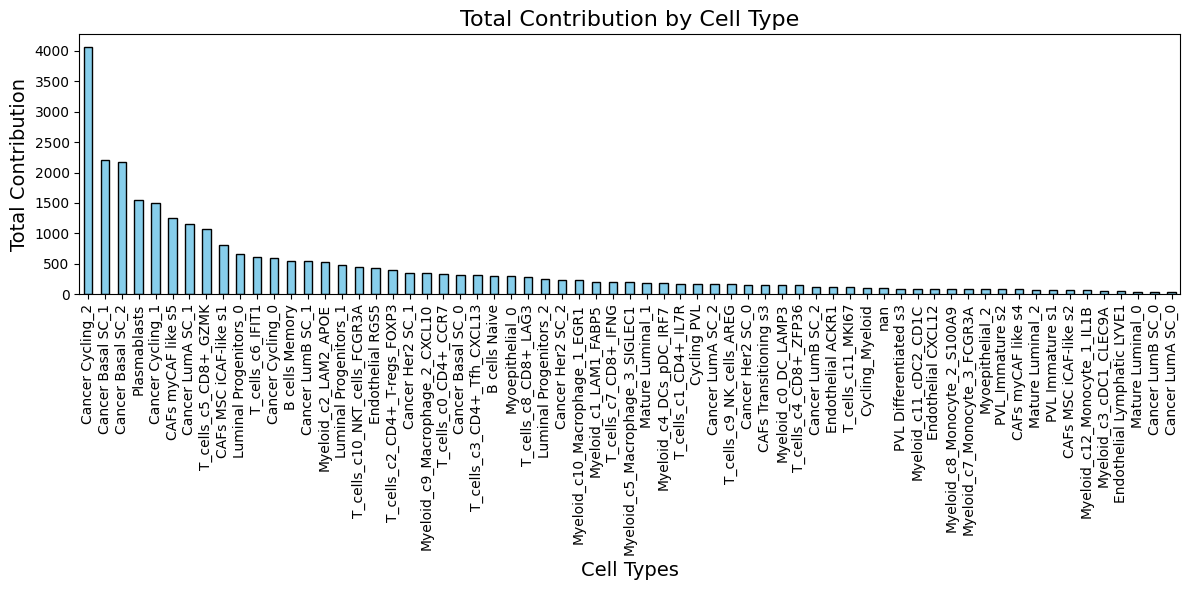

In [121]:
celltype_totals = deconvolution_results.sum(axis=0)


plt.figure(figsize=(12, 6))
celltype_totals.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Total Contribution by Cell Type", fontsize=16)
plt.ylabel("Total Contribution", fontsize=14)
plt.xlabel("Cell Types", fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [122]:
N = 10
top_celltypes = deconvolution_results.sum(axis=0).sort_values(ascending=False).index[:N]
top_celltypes

Index(['Cancer Cycling_2', 'Cancer Basal SC_1', 'Cancer Basal SC_2',
       'Plasmablasts', 'Cancer Cycling_1', 'CAFs myCAF like s5',
       'Cancer LumA SC_1', 'T_cells_c5_CD8+_GZMK', 'CAFs MSC iCAF-like s1',
       'Luminal Progenitors_0'],
      dtype='object')

# Scatterpie

## Function

In [ ]:

def plot_spatial_scatterpie(x, y, cell_types=None, img=None, scatterpie_alpha=1, 
                             pie_scale=0.4, degrees=None, axis=None,
                             show_labels=True, output_file=None, figsize=(10, 10)):
    """
    Plots a spatial scatterpie chart.

    Parameters:
    - x: DataFrame or ndarray, coordinates of spots. Must have columns ['coord_x', 'coord_y'].
    - y: DataFrame or ndarray, proportions of cell types. Row indices must match `x`.
    - cell_types: List of cell types to plot. Default is all columns in `y`.
    - img: Background image to plot. Default is None.
    - scatterpie_alpha: Alpha transparency for pie charts. Default is 1.
    - pie_scale: Scaling factor for pie chart size. Default is 0.4.
    - degrees: Rotation angle for the image (if provided). Default is None.
    - axis: Axis for mirroring the image ('h' for horizontal, 'v' for vertical). Default is None.
    - show_labels: bool, whether to show labels for cell types.
    - output_file: File path to save the plot as a PDF. Default is None.
    - figsize: Tuple, size of the figure. Default is (10, 10).

    Returns:
    - A matplotlib plot.
    - If `output_file` is provided, the plot is saved to the specified file.
    """
    # Convert inputs to DataFrame if necessary
    if isinstance(x, np.ndarray):
        x = pd.DataFrame(x, columns=['coord_x', 'coord_y'])

    if isinstance(y, np.ndarray):
        y = pd.DataFrame(y)

    # Validate inputs
    if not set(['coord_x', 'coord_y']).issubset(x.columns):
        raise ValueError("`x` must contain 'coord_x' and 'coord_y' columns.")

    if cell_types is None:
        cell_types = y.columns.tolist()

    if len(cell_types) > y.shape[1]:
        raise ValueError("Length of `cell_types` exceeds number of columns in `y`.")

    if not np.all(x.index == y.index):
        raise ValueError("Indices of `x` and `y` must match.")

    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)

    if img is not None:
        ax.imshow(img, extent=[x['coord_x'].min(), x['coord_x'].max(),
                               x['coord_y'].min(), x['coord_y'].max()],
                  aspect='auto')
    
    
    patches = []
    colors = plt.cm.tab10(np.linspace(0, 1, len(cell_types)))
    
    for i, (coord_x, coord_y) in x.iterrows():
        proportions = y.loc[i, cell_types]
        proportions /= proportions.sum()

        start_angle = 0
        for j, proportion in enumerate(proportions):
            if proportion > 0:
                end_angle = start_angle + 360 * proportion
                wedge = Wedge((coord_x, coord_y), pie_scale, start_angle, end_angle, 
                              color=colors[j], alpha=scatterpie_alpha)
                patches.append(wedge)
                start_angle = end_angle

    patch_collection = PatchCollection(patches, match_original=True)
    ax.add_collection(patch_collection)

    ax.set_xlim(x['coord_x'].min() - pie_scale, x['coord_x'].max() + pie_scale)
    ax.set_ylim(x['coord_y'].min() - pie_scale, x['coord_y'].max() + pie_scale)
    ax.set_aspect('equal')
    
    # Add legend for cell types
    if show_labels:
        legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10)
                          for color in colors]
        ax.legend(legend_patches, cell_types, loc='upper right', bbox_to_anchor=(1, 1), title="Cell Types")

    ax.axis('off')

    if output_file:
        plt.savefig(output_file, format='pdf', bbox_inches='tight')
    else:
        plt.show()



## Run

In [73]:
TNBC_adata.obs['batch'].value_counts()

batch
7     4875
10    4744
6     1211
9     1141
Name: count, dtype: int64

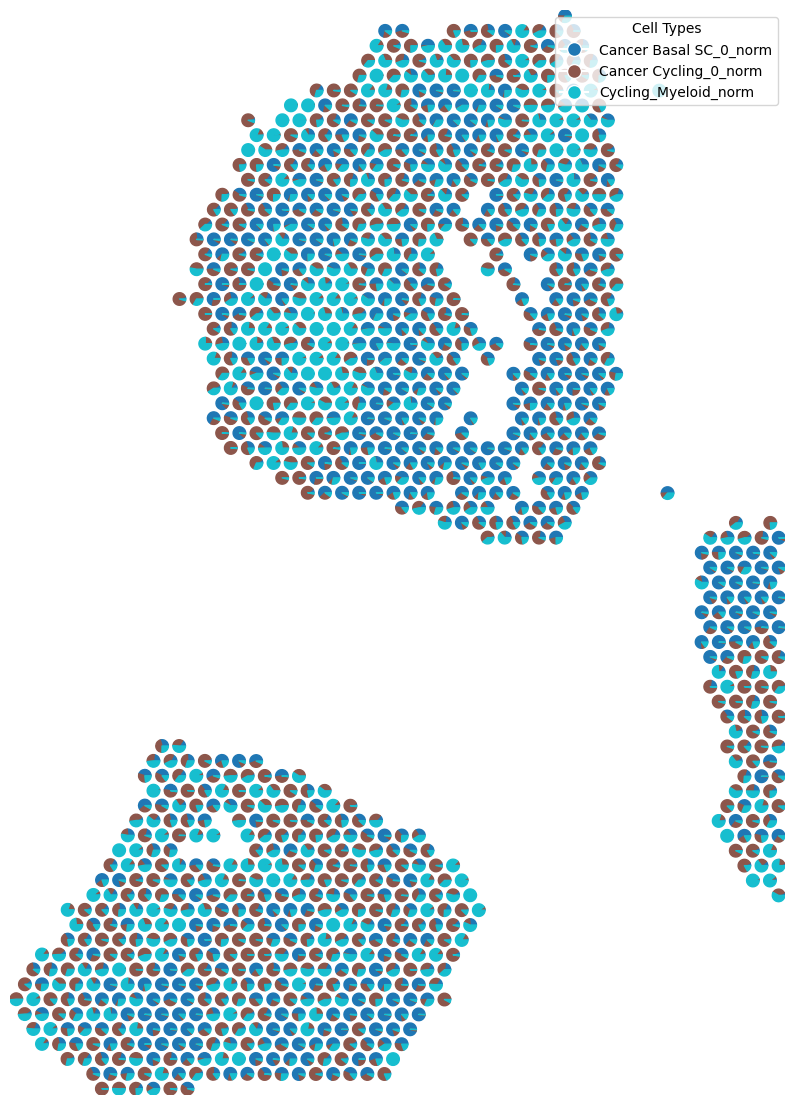

In [95]:

TNBC_adata_sub = TNBC_adata[TNBC_adata.obs['batch'] == '6']


index = TNBC_adata_sub.obs.index
x = pd.DataFrame(TNBC_adata_sub.obsm['spatial'], index=index, columns=['coord_x', 'coord_y'])
scale_factor = 50
x['coord_x'] /= scale_factor
x['coord_y'] /= scale_factor

normalized_deconv_results = pd.DataFrame(TNBC_adata_sub.obsm['normalized_deconv_results'])
y = normalized_deconv_results[['Cancer Basal SC_0_norm', 'Cancer Cycling_0_norm', 'Cycling_Myeloid_norm']]


plot_spatial_scatterpie(
    x=x,
    y=y,
    cell_types=['Cancer Basal SC_0_norm', 'Cancer Cycling_0_norm', 'Cycling_Myeloid_norm'],
    img=None,
    scatterpie_alpha=1,
    pie_scale=0.8,
    degrees=None,
    axis=None,
    show_labels=True,
    #output_file="spatial_scatterpie.pdf",
    figsize=(10, 20)
)
